# Clustering Visualization

Visualize character clustering results from the tree refinement algorithm.

**Contents:**
1. Document summary — cluster counts and statistics
2. Cluster Means Gallery (Sorted by Size) — visual overview of cluster centroids
3. Cluster Means Gallery (Sorted by Italicness) - visual overview of cluster centroids & italic detection result

In [1]:
# ── Configuration ─────────────────────────────────────────────────────

# Paths
CHARNET_ROOT = "../examples/charnet"  # folder with document subfolders
IMAGE_ROOT   = "../examples/imgs"     # for page overlays

# Document to inspect (subfolder name)
DOCUMENT = "BNE_1001_615_T-55281-18"

In [2]:
# ── Imports ───────────────────────────────────────────────────────────

import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 9,
    "axes.titlesize": 11,
})

In [3]:
# ── Load clustering results ───────────────────────────────────────────

doc_dir = Path(CHARNET_ROOT) / DOCUMENT
cluster_path = doc_dir / "clusters_all.npz"
italic_path = doc_dir / "italic_labels.npz"

assert cluster_path.exists(), f"Clusters not found: {cluster_path}"

cluster_data = np.load(str(cluster_path), allow_pickle=True)

cluster_info = cluster_data["cluster_labels"]   # (K,) cluster info
cluster_labels = cluster_info[:, 0]          # (K,) cluster majority label
cluster_prop = cluster_info[:, 1]            # (K,) proportion of majority label in cluster
cluster_counts = cluster_info[:, 2]          # (K,) number of chars in cluster
cluster_means  = cluster_data["cluster_means"]    # (K, 40, 32) centroids
cluster_italic  = cluster_data["cluster_italic"]      # (K,) Proportion of italic chars in each cluster

# Optional: italic labels
if italic_path.exists():
    italic_data = np.load(str(italic_path), allow_pickle=True)
    char_italic = italic_data["char_italic"]
    has_italic = True
else:
    char_italic = np.zeros(len(cluster_labels), dtype=bool)
    has_italic = False

n_chars = sum(cluster_counts)
n_clusters = len(cluster_means)

print(f"Document: {DOCUMENT}")
print(f"Characters: {n_chars:,}")
print(f"Clusters: {n_clusters}")
print(f"Italic data: {'yes' if has_italic else 'no'}")

Document: BNE_1001_615_T-55281-18
Characters: 48,775
Clusters: 414
Italic data: yes


---
## 1. Document Summary

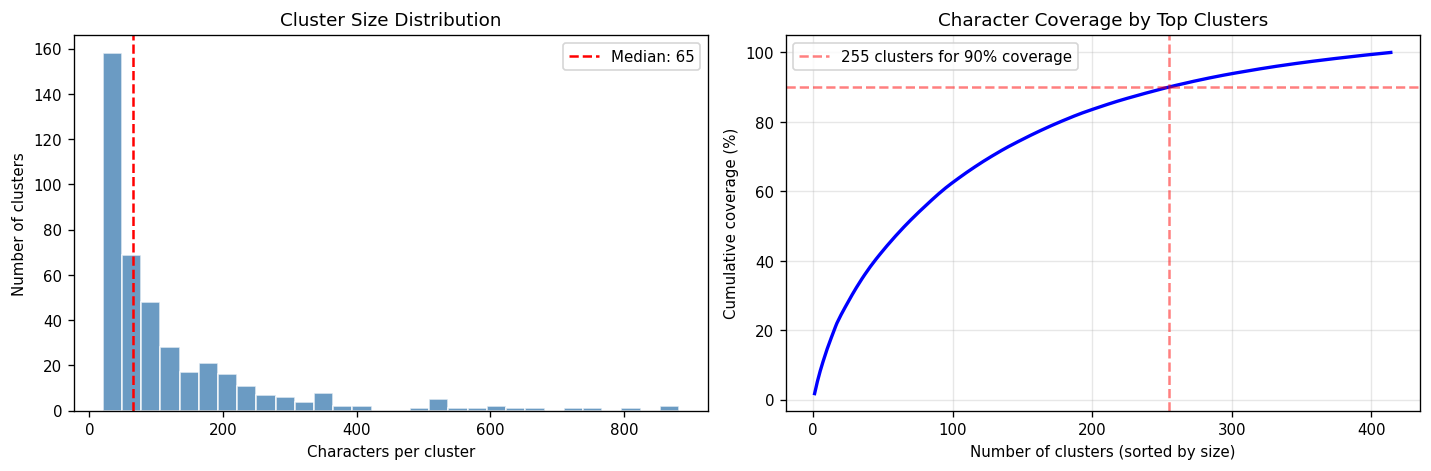


Top 10 clusters cover 14.7% of characters
Top 50 clusters cover 43.0% of characters


In [4]:
# ── Summary statistics ────────────────────────────────────────────────

# Cluster size distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of cluster sizes
ax = axes[0]
ax.hist(cluster_counts, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.set_xlabel("Characters per cluster")
ax.set_ylabel("Number of clusters")
ax.set_title("Cluster Size Distribution")
ax.axvline(np.median(cluster_counts), color="red", linestyle="--", 
           label=f"Median: {np.median(cluster_counts):.0f}")
ax.legend()

# Cumulative coverage
ax = axes[1]
sorted_counts = np.sort(cluster_counts)[::-1]
cumsum = np.cumsum(sorted_counts) / n_chars * 100
ax.plot(range(1, len(cumsum) + 1), cumsum, "b-", linewidth=2)
ax.set_xlabel("Number of clusters (sorted by size)")
ax.set_ylabel("Cumulative coverage (%)")
ax.set_title("Character Coverage by Top Clusters")
ax.axhline(90, color="red", linestyle="--", alpha=0.5)
# Find how many clusters cover 90%
n_for_90 = np.searchsorted(cumsum, 90) + 1
ax.axvline(n_for_90, color="red", linestyle="--", alpha=0.5,
           label=f"{n_for_90} clusters for 90% coverage")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

print(f"\nTop 10 clusters cover {cumsum[9]:.1f}% of characters")
print(f"Top 50 clusters cover {cumsum[min(49, len(cumsum)-1)]:.1f}% of characters")

---
## 2. Cluster Means Gallery (Sorted by Size)

Visual overview of all cluster centroids, sorted by size.

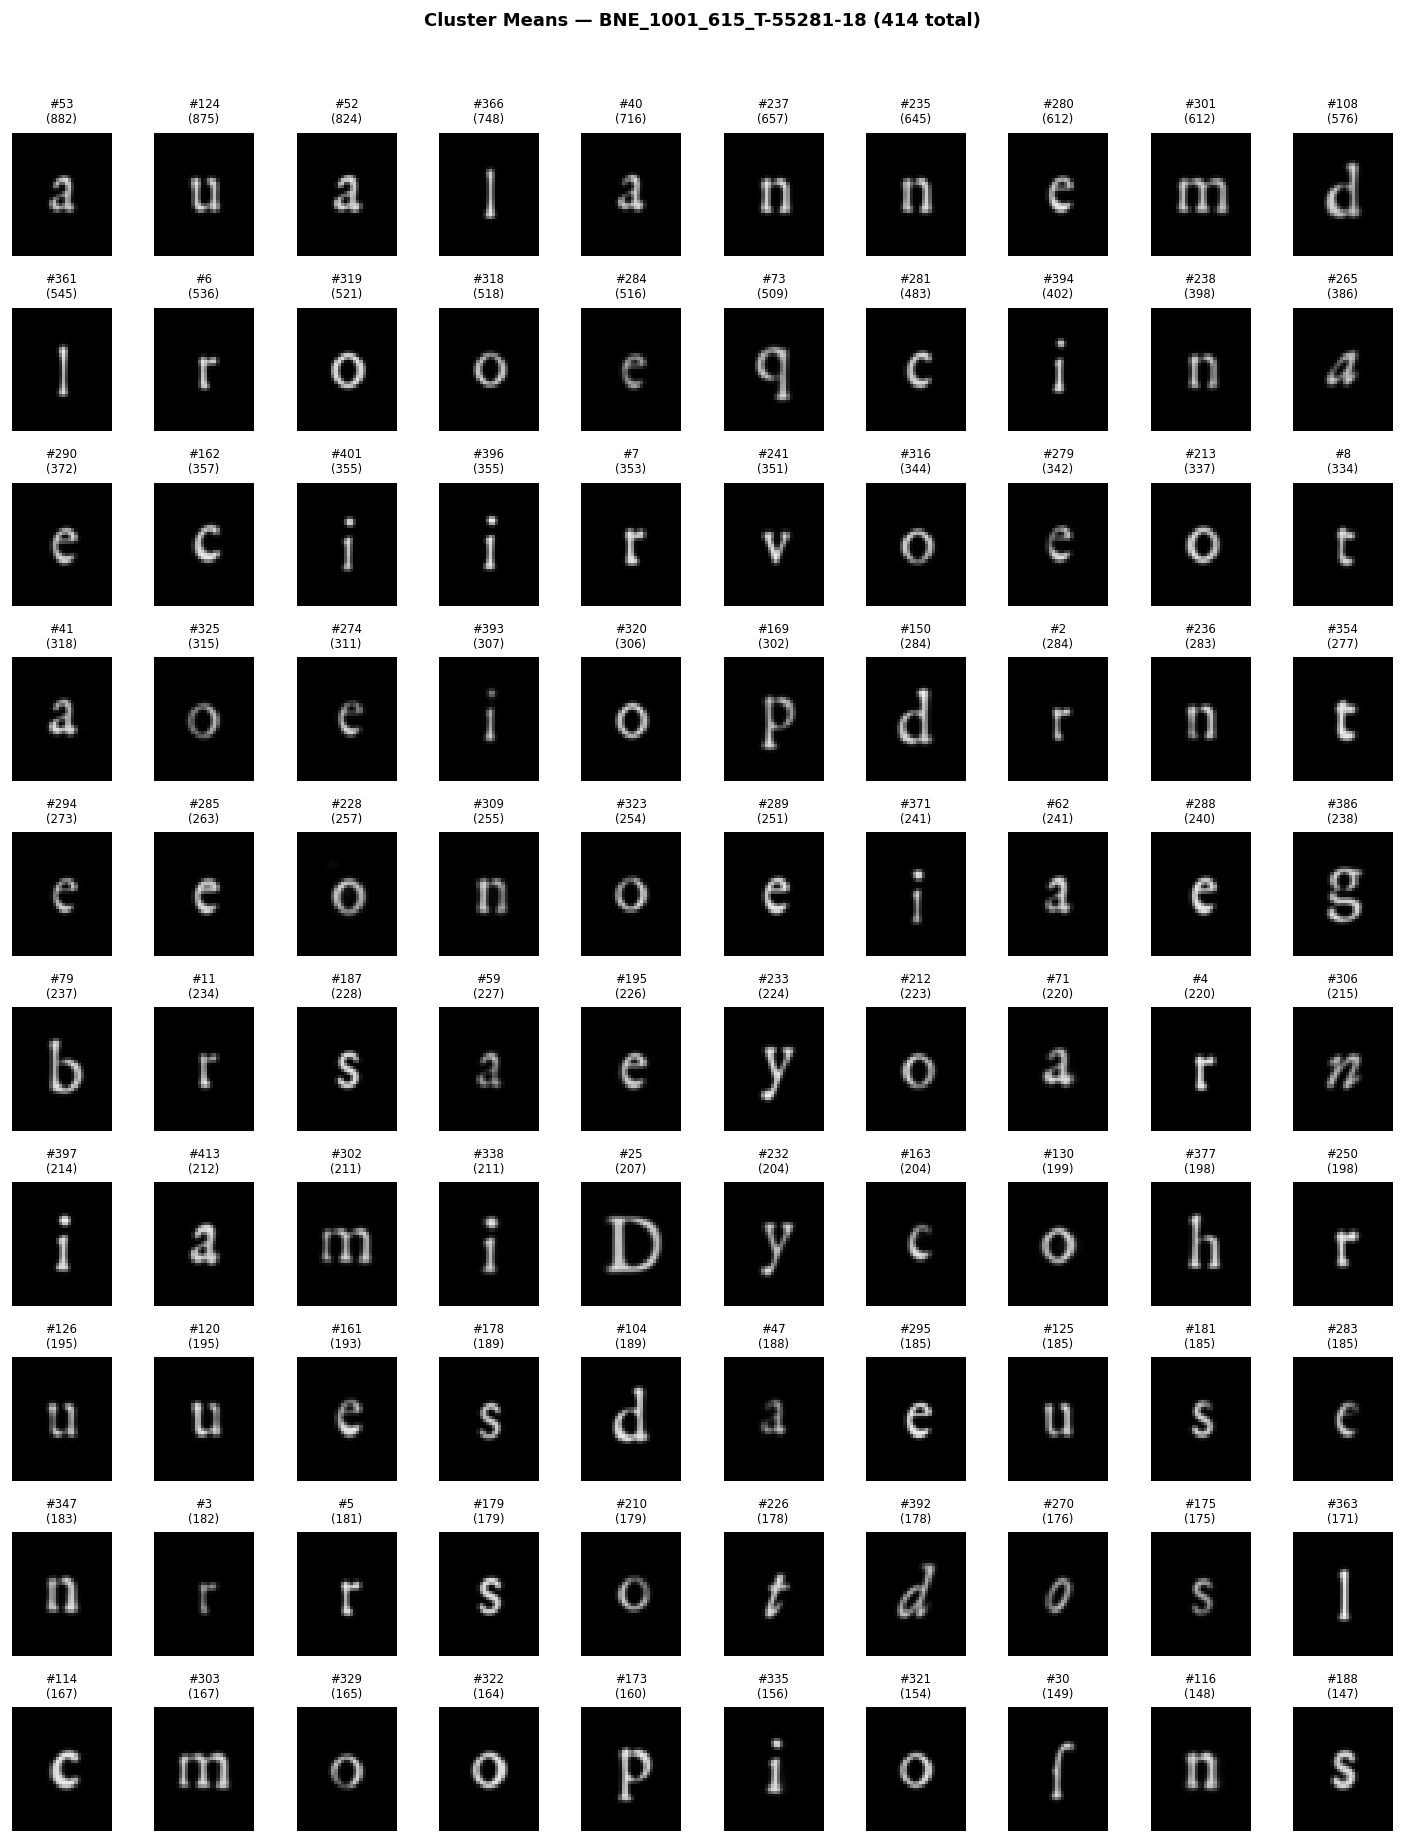

In [5]:
# ── Plot cluster means ────────────────────────────────────────────────

# Sort by cluster size
order = np.argsort(cluster_counts)[::-1]

# Determine grid size
n_show = min(100, n_clusters)  # show at most 100
cols = 10
rows_grid = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(cols * 1.2, rows_grid * 1.5))
axes = np.atleast_2d(axes)

for idx in range(rows_grid * cols):
    row, col = idx // cols, idx % cols
    ax = axes[row, col]
    
    if idx < n_show:
        cid = order[idx]
        ax.imshow(cluster_means[cid], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"#{cid}\n({cluster_counts[cid]})", fontsize=7)
    ax.set_axis_off()

fig.suptitle(f"Cluster Means — {DOCUMENT} ({n_clusters} total)", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

## 3. Cluster Means Gallery (Sorted by Italicness)

Visual overview of all cluster centroids, sorted by proportion of italic characters.

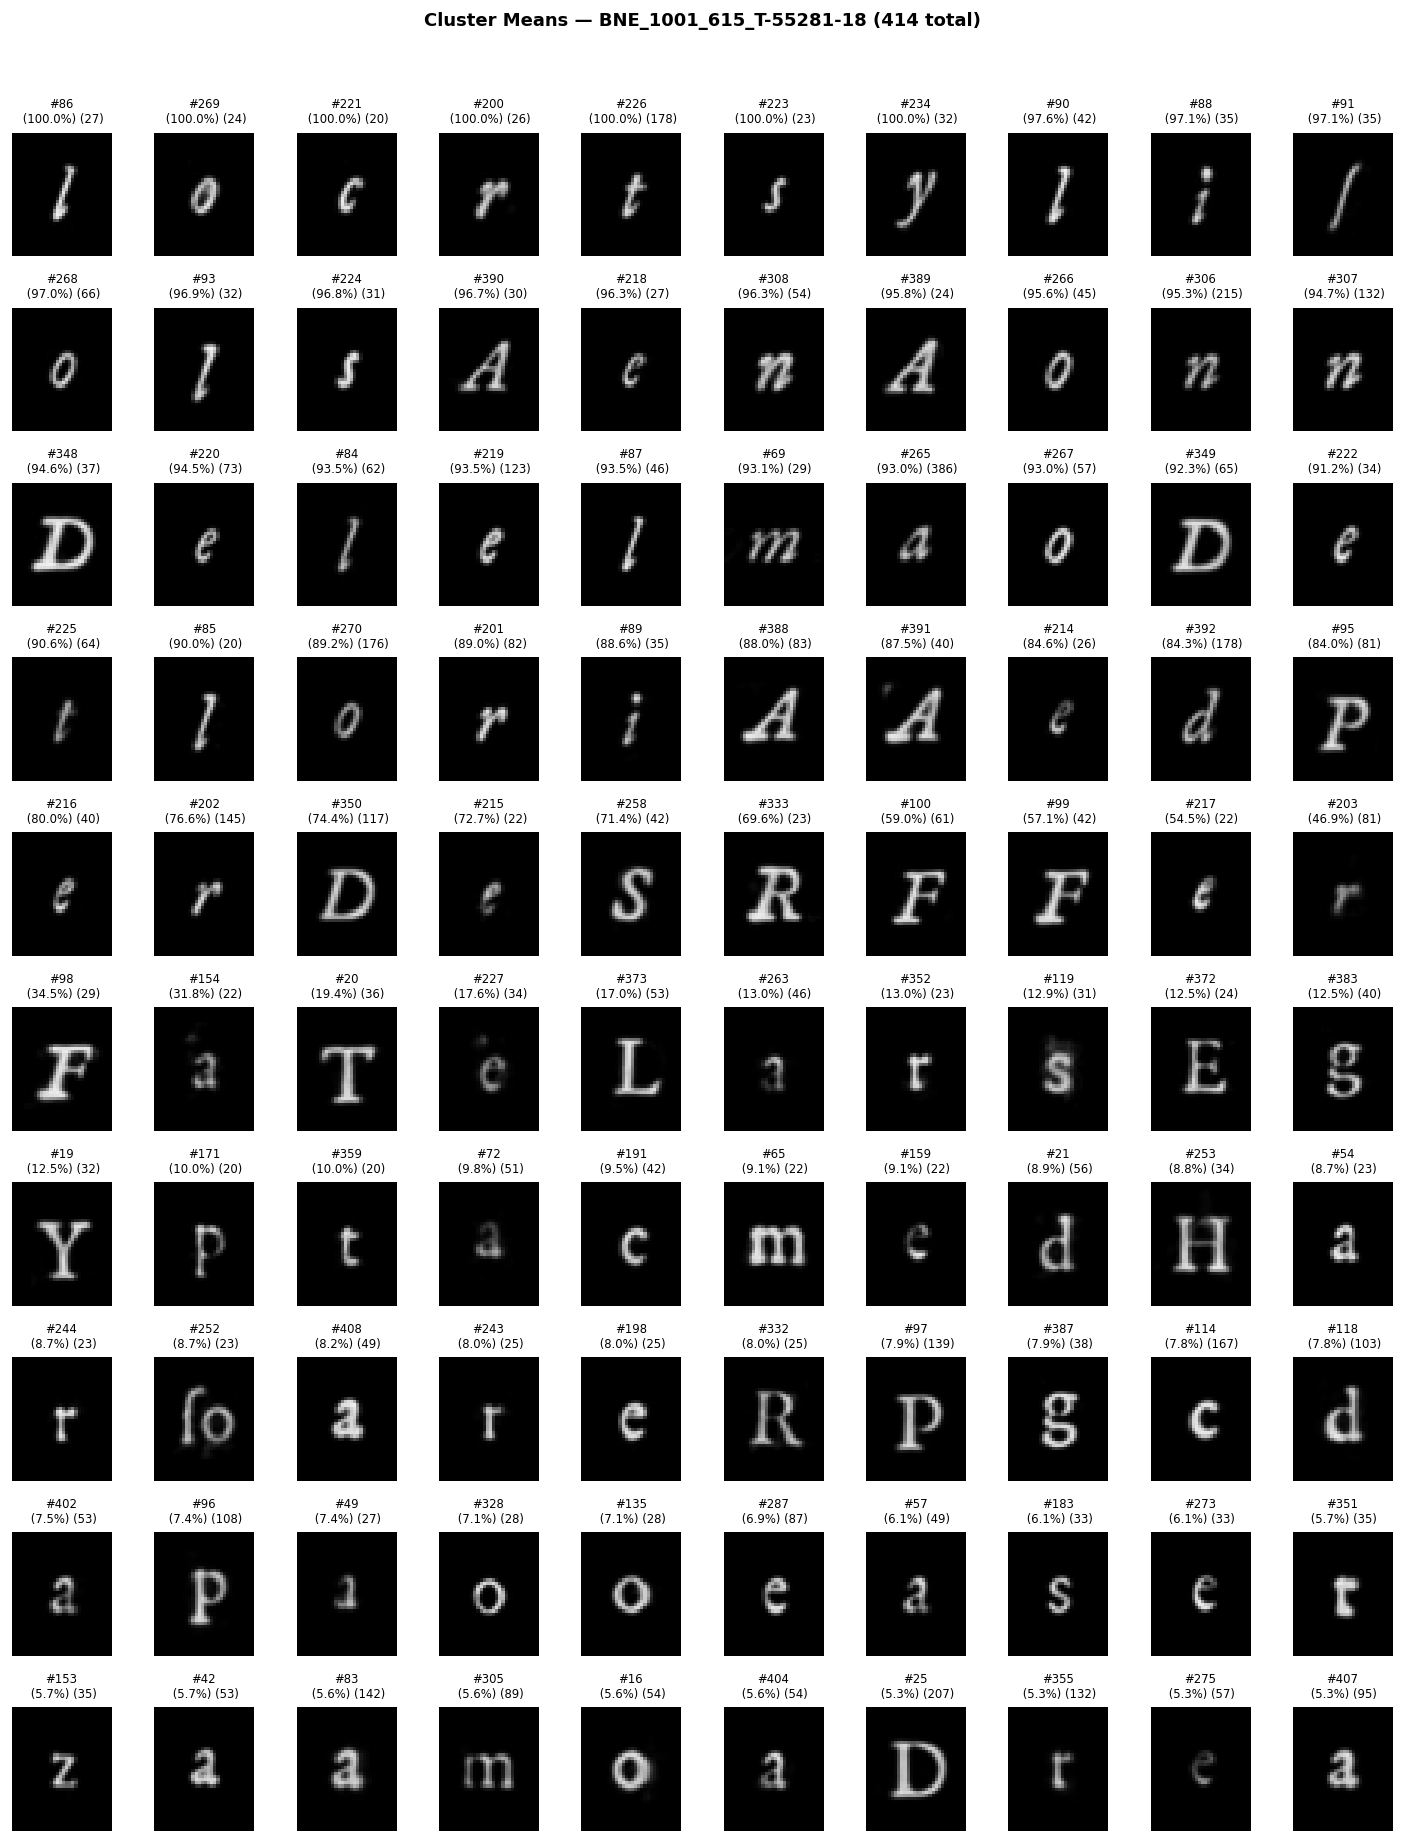

In [6]:
# ── Plot cluster means ────────────────────────────────────────────────

# Sort by cluster size
order = np.argsort(cluster_italic)[::-1]

# Determine grid size
n_show = min(100, n_clusters)  # show at most 100
cols = 10
rows_grid = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows_grid, cols, figsize=(cols * 1.2, rows_grid * 1.5))
axes = np.atleast_2d(axes)

for idx in range(rows_grid * cols):
    row, col = idx // cols, idx % cols
    ax = axes[row, col]
    
    if idx < n_show:
        cid = order[idx]
        ax.imshow(cluster_means[cid], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"#{cid}\n ({cluster_italic[cid]:.1%}) ({cluster_counts[cid]})", fontsize=7)
    ax.set_axis_off()

fig.suptitle(f"Cluster Means — {DOCUMENT} ({n_clusters} total)", fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()